In [1]:
from morphapi.api.allenmorphology import AllenMorphology


am = AllenMorphology()


# Select mouse neurons in the primary visual cortex
neurons = am.neurons.loc[
    (am.neurons.species == "Mus musculus")
    & (am.neurons.structure_area_abbrev == "VISp")
]

# Download some of these neurons
neurons = am.download_neurons(neurons[:5].id.values)

In [1]:
from pathlib import Path
from brainrender._io import load_mesh_from_file
from myterial import orange
from rich import print
from brainglobe_atlasapi import BrainGlobeAtlas
from brainrender import Scene
import brainrender
from brainrender.actors import Points, Line
import numpy as np

bg_atlas = BrainGlobeAtlas("allen_mouse_100um", check_latest=False)
bg_atlas.lookup_df.acronym.values
region = 'TH'
obj_file = str(bg_atlas.meshfile_from_structure(region))


mesh = load_mesh_from_file(obj_file, alpha=0.2, color="green")


In [2]:
bg_atlas.lookup_df.acronym


0       root
1       grey
2         CH
3        CTX
4      CTXpl
       ...  
835       V3
836       AQ
837       V4
838      V4r
839        c
Name: acronym, Length: 840, dtype: object

In [ ]:
from utils import slice_util
slice_util.combine_obj_files([str(bg_atlas.root_dir).replace("\\",'/')+"/meshes"],'output')

In [4]:
neurons[0].create_mesh()


({'soma': <vedo.mesh.Mesh at 0x21945723250>,
  'basal_dendrites': <vedo.mesh.Mesh at 0x219457513d0>,
  'apical_dendrites': <vedo.mesh.Mesh at 0x21945733dd0>,
  'axon': None},
 <vedo.mesh.Mesh at 0x21945751dd0>)

In [2]:
from vedo import *
import random
from matplotlib import colormaps
from vedo.colors import colors
from operator import itemgetter
import os
from vtk.util import numpy_support


In [3]:
meshes = load_obj('output/meshes.obj')



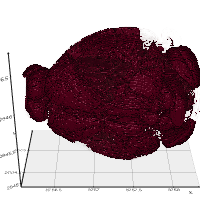

In [4]:
_vol = meshes[0].normalize().binarize()
_vol

In [9]:
_vol_norm = _vol.clone().isosurface(4, flying_edges=False).pos(0,0,0).color('yellow5', 0.5)